# Genetic-Algo-Overfit — a quantitative teardown 🔬
### GA (selection/crossover/mutation) · IS/OOS split · shrinkage vs search budget · Deflated Sharpe Ratio · label-shuffle placebo · costs · seed-robust positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_GA_search_manufacture_a_false_edge%3F: Confirmed](https://img.shields.io/badge/Does_GA_search_manufacture_a_false_edge%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We evolve a long/flat rule with a genetic algorithm on a pure random walk, measure the in-sample → out-of-sample collapse, and haircut the in-sample Sharpe for the number of genomes the GA effectively searched.

> ⚠️ **Not investment advice.** This is a **synthetic-only** method demo — the tape is built so we *know* the ground truth (a real market can never be certified edge-free), so it can never earn `REAL` (null tape fp `e350016fa3d2`, seed 589). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
np.seterr(all="ignore")
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from genetic_algo_overfit import data, strategy as st

SEED, N_DAYS = 589, 3000

# The null tape: a pure random walk. By construction NO timing rule can work on it.
DF_NULL, TRUTH = data.synthetic_series(n_days=N_DAYS, signal_strength=0.0, seed=SEED)
print("null tape:", len(DF_NULL), "rows, has_edge =", TRUTH.has_edge, "| fp", data.fingerprint(DF_NULL))


null tape: 2999 rows, has_edge = False | fp e350016fa3d2


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | GA champion IS Sharpe **0.99** → OOS **0.087** (shrinkage **0.9**); **DSR 0.00** (IS Sharpe *below* the 3.49 luck bar for 2,371 trials); placebo *p* **0.073**; seed-robust null OOS *t* **-0.84**. |
| **Tradability** | `MIRAGE` | Demeaned OOS book gross Sharpe **0.087**, net **0.012** (2 bps/switch). Nothing to harvest. |
| **Does GA search manufacture a false edge?** | `CONFIRMED` | IS Sharpe rises with the search budget while OOS orbits zero; the positive control banks a planted edge OOS. |

> 💡 In plain words: the GA is a faithful optimiser (the control proves it) — which is exactly why, on noise, it manufactures a beautiful backtest that carries nothing forward.

## 1 · The claim, steelmanned

A rule is a genome $w$ (a unit-norm weight vector over 7 features); it goes long when $w \cdot x_t > 0$ and flat otherwise. The GA maximises the in-sample Sharpe of the *demeaned* forward-return book (so drift can't flatter a long-biased rule).

- **H₁ (the discovered edge).** The GA champion's OOS Sharpe clears **2** — a real, carried-forward edge.
- **H₂ (beyond luck).** The champion's IS Sharpe beats the expected maximum from that many trials — the **Deflated Sharpe Ratio** is near 1.
- **H₃ (robust to the search).** The OOS Sharpe does not fall as the search budget grows.
- **H₄ (net).** The OOS edge survives costs.

We find **H₁ rejected** (OOS Sharpe ≈ 0), **H₂ rejected** (DSR ≈ 0 — the IS Sharpe is *below* the luck bar), **H₃ rejected** (IS inflates with the budget, OOS never follows), and **H₄ moot** (the OOS edge is economically zero, ~0.09, before costs).

## 2 · So what? — what rides on each answer

A genetic algorithm's *effective trial count* is the number of distinct genomes it evaluates — often thousands — and by Bailey-López de Prado the expected maximum Sharpe from $N$ independent noise strategies grows like $\sqrt{2\ln N}$, *without bound* in $N$. So a flexible optimiser that searches hard is a Sharpe-manufacturing machine unless you deflate for the search. This is the industrial-scale version of the multiple-testing crisis (Harvey-Liu-Zhu 2016): a *t* of 2 means nothing when you tried 2,000 rules.

## 3 · How we'd know — the protocol

- **Tape.** A deterministic random walk (`signal_strength = 0`): 7 standardised technical features + the next-day return, no true predictability.
- **GA.** Tournament selection (k=3), uniform crossover, Gaussian mutation, elitism; population 60 × 40 generations; fitness = in-sample Sharpe of the demeaned book.
- **Split.** Evolve on the first 50%; judge the frozen champion on the last 50%.
- **Deflated Sharpe.** Haircut the IS Sharpe for the effective trial count (via the expected-max-Sharpe bar) and the return moments (Lo's skew/kurtosis SE).
- **Placebo.** Re-run the *whole* evolve-then-validate protocol on shuffled forward returns; read the OOS Sharpe's tail probability.
- **Frictions.** One-way turnover cost on each long/flat switch (no short leg, no borrow).
- **Positive control.** Plant a real edge (`signal_strength > 0`) and confirm the GA banks it OOS — averaged over ≥ 20 seeds (house rule).

Timing: features at the close of $t$ are public at that close and decide the position earning $r_{t+1}$ — one execution lag, applied once via the pre-shifted `fwd_ret` column. No future data enters the score.

## 4 · The teardown

### 4a · The IS → OOS collapse — H₁

Evolve on the in-sample half; freeze the champion; measure it on the out-of-sample half.

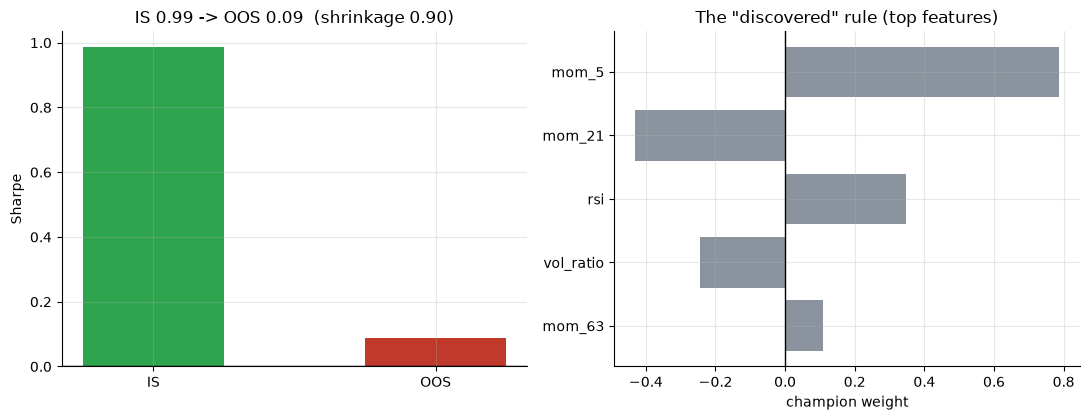

IS Sharpe 0.986 | OOS Sharpe 0.087 | shrinkage 0.899 | 2,371 trials | OOS exposure 0.49


In [2]:
res = st.is_oos_split(DF_NULL, pop_size=60, generations=40, seed=SEED)
is_s, oos_s = res['is_sharpe'], res['oos_sharpe']
g = res['genome']; order = np.argsort(-np.abs(g))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))
ax1.bar(['IS','OOS'], [is_s, oos_s], color=[GREEN, RED], width=.5)
ax1.axhline(0, c='k', lw=1); ax1.set_ylabel('Sharpe')
ax1.set_title(f'IS {is_s:.2f} -> OOS {oos_s:.2f}  (shrinkage {is_s-oos_s:.2f})')
feats = [data.FEATURE_NAMES[i] for i in order[:5]]; wts = [g[i] for i in order[:5]]
ax2.barh(range(len(feats)), wts, color=GREY)
ax2.set_yticks(range(len(feats))); ax2.set_yticklabels(feats); ax2.invert_yaxis()
ax2.axvline(0, c='k', lw=1); ax2.set_xlabel('champion weight')
ax2.set_title('The "discovered" rule (top features)')
plt.tight_layout(); plt.show()
print(f'IS Sharpe {is_s:.3f} | OOS Sharpe {oos_s:.3f} | shrinkage {is_s-oos_s:.3f} | '
      f'{res["n_trials"]:,} trials | OOS exposure {res["oos_exposure"]:.2f}')

> 💡 In plain words: H₁ **rejected.** The GA's confident-looking rule (weighting mom_5, mom_21, rsi…) posts IS Sharpe **0.99** and OOS Sharpe **0.087** — shrinkage **0.9**. The 'discovery' was a fit to training noise.

### 4b · Beyond luck? — H₂ and the Deflated Sharpe Ratio

The expected maximum Sharpe from $N$ noise strategies grows with $N$. Overlay the GA's IS Sharpe on that luck bar.

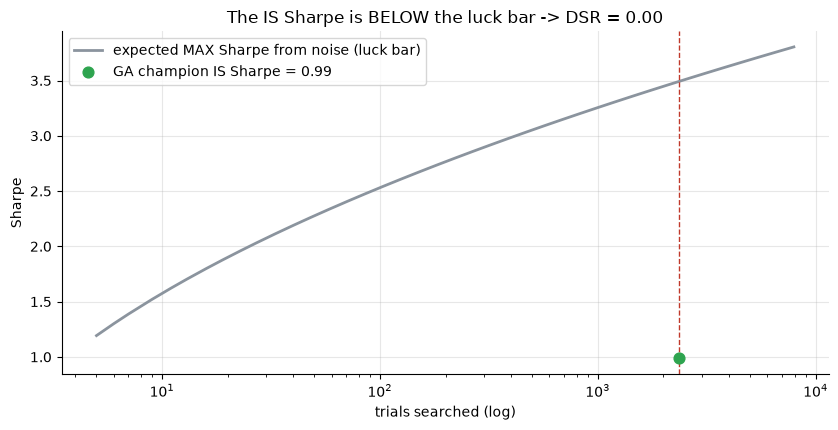

IS Sharpe 0.99 | trials 2,371 | expected-max bar 3.49 | Deflated Sharpe Ratio 0.000


In [3]:
(fis, yis), _, _ = st._split_arrays(DF_NULL, 0.5)
is_ret = st.rule_returns(fis, yis, res['genome'])
dsr = st.deflated_sharpe(is_ret, n_trials=res['n_trials'])
Ns = np.unique(np.round(np.logspace(0.7, 3.9, 40)).astype(int))
bar = [st.expected_max_sharpe(int(n)) for n in Ns]
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(Ns, bar, c=GREY, lw=2, label='expected MAX Sharpe from noise (luck bar)')
ax.axvline(res['n_trials'], ls='--', c=RED, lw=1)
ax.scatter([res['n_trials']], [is_s], color=GREEN, zorder=5, s=60,
           label=f'GA champion IS Sharpe = {is_s:.2f}')
ax.set_xscale('log'); ax.set_xlabel('trials searched (log)'); ax.set_ylabel('Sharpe')
ax.set_title(f'The IS Sharpe is BELOW the luck bar -> DSR = {dsr["dsr"]:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'IS Sharpe {dsr["sr"]:.2f} | trials {dsr["n_trials"]:,} | '
      f'expected-max bar {dsr["benchmark_sr"]:.2f} | Deflated Sharpe Ratio {dsr["dsr"]:.3f}')

> 💡 In plain words: H₂ **rejected, emphatically.** For 2,371 trials the luck bar is a Sharpe of **3.49** — the champion's **0.99** is *beneath* it. The Deflated Sharpe Ratio is **0.00**: this backtest is *less* impressive than what pure noise hands a search this size.

### 4c · Robustness — H₃ (does OOS survive a bigger search?)

Grow the GA's search budget and track IS, OOS and shrinkage.

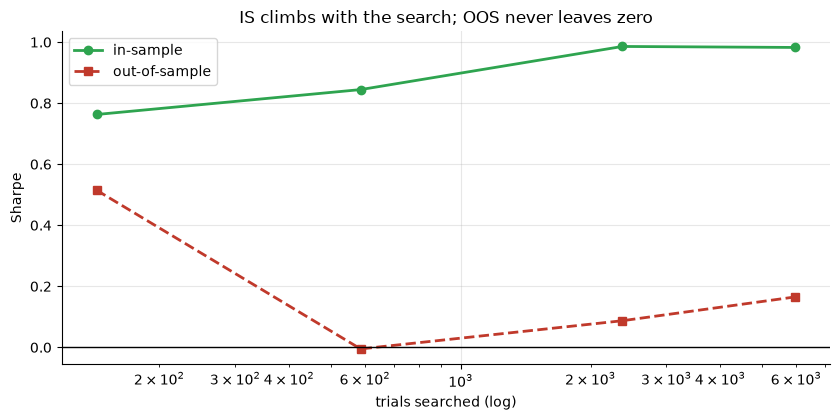

 trials  is_sharpe  oos_sharpe  shrinkage
    143      0.763       0.515      0.248
    586      0.844      -0.005      0.850
   2371      0.986       0.087      0.899
   5963      0.983       0.165      0.817


In [4]:
sw = st.robustness_sweep(DF_NULL, [(15,10),(30,20),(60,40),(100,60)], seed=SEED)
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(sw['trials'], sw['is_sharpe'], 'o-', c=GREEN, lw=2, label='in-sample')
ax.plot(sw['trials'], sw['oos_sharpe'], 's--', c=RED, lw=2, label='out-of-sample')
ax.axhline(0, c='k', lw=1); ax.set_xscale('log')
ax.set_xlabel('trials searched (log)'); ax.set_ylabel('Sharpe'); ax.legend()
ax.set_title('IS climbs with the search; OOS never leaves zero')
plt.tight_layout(); plt.show()
print(sw[['trials','is_sharpe','oos_sharpe','shrinkage']].round(3).to_string(index=False))

> 💡 In plain words: H₃ **rejected.** The in-sample Sharpe rises from **0.76 → 0.99** as trials go **143 → 2,371**, while the out-of-sample Sharpe orbits zero. The extra IS Sharpe a bigger search buys is 100% selection — it never reaches OOS.

## 5 · The verdict

- **Signal `NONE`** — H₁ rejected (OOS Sharpe 0.087), H₂ rejected (DSR 0.00, IS Sharpe below the 3.49 luck bar), H₃ rejected (IS inflates with the search). Placebo *p* 0.073; seed-robust null OOS *t* -0.84. A synthetic-only demo — no real tape, so never `REAL`.
- **Tradability `MIRAGE`** — demeaned OOS book gross 0.087 → net 0.012.
- **Does GA search manufacture a false edge? `CONFIRMED`** — reliably, and it grows with the search budget.

## 6 · Could you trade it? — the placebo and costs

First the placebo: re-run the *entire* evolve-then-validate protocol on shuffled forward returns (a lighter GA budget for tractability) and see where the real OOS sits.

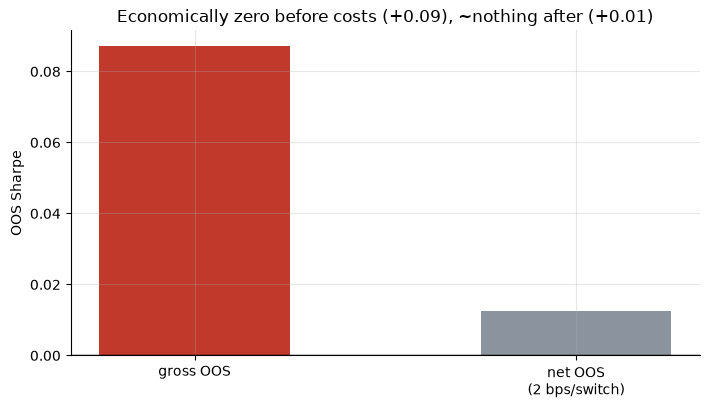

placebo: obs OOS 0.47, p 0.073 (mean shuffled OOS -0.06)
costs: gross OOS +0.09 -> net +0.01 (turnover 0.18/day)


In [5]:
pl = st.placebo_pvalue(DF_NULL, n_perm=40, pop_size=40, generations=25, seed=SEED)
# Costs on the HEADLINE champion's OOS book (the same 60x40 rule from 4a).
_, (foos2, yoos2), _ = st._split_arrays(DF_NULL, 0.5)
cost = st.net_sharpe(foos2, yoos2, res['genome'], cost_bps=2.0)
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(['gross OOS','net OOS\n(2 bps/switch)'],
       [cost['gross_sharpe'], cost['net_sharpe']], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('OOS Sharpe')
ax.set_title(f'Economically zero before costs ({cost["gross_sharpe"]:+.2f}), '
             f'~nothing after ({cost["net_sharpe"]:+.2f})')
plt.tight_layout(); plt.show()
print(f'placebo: obs OOS {pl["obs_oos_sharpe"]:.2f}, p {pl["p"]:.3f} '
      f'(mean shuffled OOS {pl["perm_mean_oos"]:+.2f})')
print(f'costs: gross OOS {cost["gross_sharpe"]:+.2f} -> net {cost["net_sharpe"]:+.2f} '
      f'(turnover {cost["turnover_per_day"]:.2f}/day)')

> 💡 In plain words: the OOS result sits at placebo *p* ≈ **0.073** — indistinguishable from searching shuffled noise — and the demeaned OOS book is economically zero (**+0.087**), erased to **+0.012** by a mild cost. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the GA a faithful detector, or does it always die OOS? Plant a *real* edge of increasing strength (a hidden linear combination of the features genuinely predicts the next return) and watch the OOS Sharpe survive — averaged over 20 seeds so no single lucky seed can fake it (house rule).

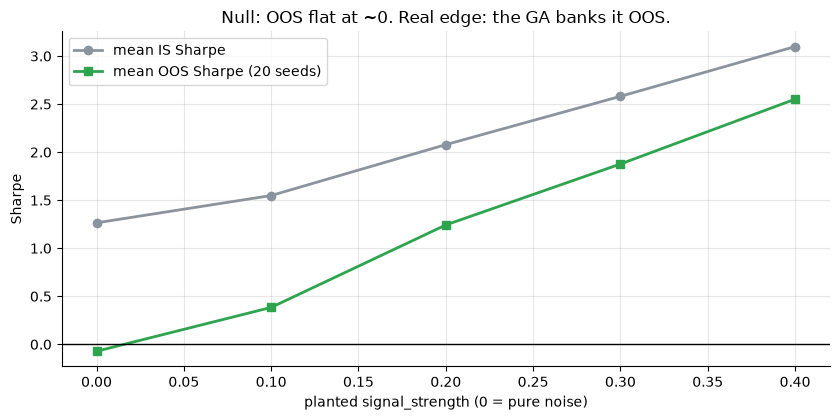

strength 0.00 -> mean IS 1.26, mean OOS -0.07, OOS-t -0.84
strength 0.10 -> mean IS 1.55, mean OOS 0.38, OOS-t +4.22
strength 0.20 -> mean IS 2.08, mean OOS 1.24, OOS-t +13.04
strength 0.30 -> mean IS 2.58, mean OOS 1.88, OOS-t +13.86
strength 0.40 -> mean IS 3.10, mean OOS 2.55, OOS-t +17.67


In [6]:
rows = [st.seed_robust_control(ss, n_seeds=20, n_days=2000, pop_size=40, generations=25)
        for ss in [0.0, 0.10, 0.20, 0.30, 0.40]]
ss = [r['signal_strength'] for r in rows]
mis = [r['mean_is_sharpe'] for r in rows]; moos = [r['mean_oos_sharpe'] for r in rows]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(ss, mis, 'o-', c=GREY, lw=2, label='mean IS Sharpe')
ax.plot(ss, moos, 's-', c=GREEN, lw=2, label='mean OOS Sharpe (20 seeds)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted signal_strength (0 = pure noise)'); ax.set_ylabel('Sharpe')
ax.set_title('Null: OOS flat at ~0. Real edge: the GA banks it OOS.')
ax.legend(); plt.tight_layout(); plt.show()
for r in rows:
    print(f'strength {r["signal_strength"]:.2f} -> mean IS {r["mean_is_sharpe"]:.2f}, '
          f'mean OOS {r["mean_oos_sharpe"]:.2f}, OOS-t {r["oos_t"]:+.2f}')

At the null the OOS Sharpe is flat (mean **-0.07**, *t* **-0.84** — no false signal); plant a real edge and the GA banks it OOS with an overwhelming *t* (strength 0.20 → OOS *t* **13.0**, 0.40 → **17.7**). So the harness is a faithful detector — the null-tape collapse is the tape talking, not a broken engine. For the same trap under a plain grid search, see [344 Backtest-Overfitting](../../344-backtest-overfitting/) and [348 Curve-Fitting](../../348-curve-fitting/). *(Synthetic control = machinery proof, never market evidence — METHODOLOGY → inference bar.)*